In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
USING_KAGGLE = True
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/keysss/kaggle_deploying
/kaggle/input/keysss/kaggle_deploying.pub


In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
private_key = user_secrets.get_secret("private")
public_key = user_secrets.get_secret("public")
private_key = private_key[:35] + private_key[35:-33].replace(' ', '\n') + private_key[-33:] + '\n'
with open('key', 'w') as f:
    f.write(private_key)
with open('key.pub', 'w') as f:
    f.write(public_key)


In [3]:
!sudo chmod 600 /kaggle/working/key
!ssh-keyscan -t ecdsa github.com
!GIT_SSH_COMMAND='sudo ssh -i /kaggle/working/key -o IdentitiesOnly=yes -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null' git clone git@github.com:maximspbu/optimizers_comparison.git
!cd optimizers_comparison && git switch sprint5

# github.com:22 SSH-2.0-0264bb16
github.com ecdsa-sha2-nistp256 AAAAE2VjZHNhLXNoYTItbmlzdHAyNTYAAAAIbmlzdHAyNTYAAABBBEmKSENjQEezOmxkZMy7opKgwFB9nkt5YRrYMjNuG5N87uRgg6CLrbo5wAdT/y6v0mKV0U2w0WZ2YB/++Tpockg=
Cloning into 'optimizers_comparison'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 103 (delta 46), reused 77 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 5.47 MiB | 20.91 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Branch 'sprint5' set up to track remote branch 'sprint5' from 'origin'.
Switched to a new branch 'sprint5'


In [4]:
%pip install lion_pytorch torch-optimizer ray[tune] adabelief-pytorch==0.2.0 -q
%pip install --upgrade seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour 

In [ ]:
import time
from copy import copy
from typing import Optional
import inspect
import os
import sys

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchinfo import summary
from torchmetrics.regression import MeanAbsolutePercentageError as MAPE, R2Score

import pandas as pd
from ray.train.torch import enable_reproducibility
from ray import tune
from ray.tune import JupyterNotebookReporter
from ray.tune.schedulers import ASHAScheduler

from torch.optim import AdamW
from optimizers_comparison.src.optimizers import AdaBound
from torch_optimizer import Adahessian as AdaHessian
from adabelief_pytorch import AdaBelief
from lion_pytorch import Lion

#notebook_dir = os.path.dirname(os.path.abspath("__file__"))

#project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

#if project_root not in sys.path:
#    sys.path.insert(0, project_root)

In [ ]:
from optimizers_comparison.src.config import setup, seed_worker, DEVICE, TORCH_GENERATOR
from optimizers_comparison.src.data_setup import get_train_valid_test_datasets
from optimizers_comparison.src.utils import create_writer, plot_results
from optimizers_comparison.src.engine import train
from optimizers_comparison.src.model_builder import SimpleRegressionModel

2025-05-13 07:10:12.046045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747120212.267794      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747120212.327871      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [7]:
setup(".")

2025-05-13 07:10:27,276	INFO worker.py:1852 -- Started a local Ray instance.
2025-05-13 07:10:27,347	INFO packaging.py:575 -- Creating a file package for local module '.'.
2025-05-13 07:10:27,426	INFO packaging.py:367 -- Pushing file package 'gcs://_ray_pkg_31c25b91c219b3a0.zip' (12.10MiB) to Ray cluster...
2025-05-13 07:10:27,511	INFO packaging.py:380 -- Successfully pushed file package 'gcs://_ray_pkg_31c25b91c219b3a0.zip'.


{'CPU': 4.0,
 'GPU': 2.0,
 'accelerator_type:T4': 1.0,
 'memory': 20685609370.0,
 'node:172.19.2.2': 1.0,
 'node:__internal_head__': 1.0,
 'object_store_memory': 8865261158.0}


In [8]:
# train_filename = (
#     "/kaggle/input/california-housing-prices/S7_california_housing_train.csv"
# )
# test_filename = "/kaggle/input/california-housing-prices/S7_california_housing_test.csv"

train_filename = "optimizers_comparison/data/california_housing_train.csv"
test_filename = "optimizers_comparison/data/california_housing_test.csv"

train_dataset, valid_dataset, test_dataset = get_train_valid_test_datasets(
    train_filename=train_filename, test_filename=test_filename
)


In [10]:
summary(SimpleRegressionModel())

Layer (type:depth-idx)                   Param #
SimpleRegressionModel                    --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       576
│    └─Identity: 2-2                     --
│    └─ReLU: 2-3                         --
│    └─Identity: 2-4                     --
│    └─Linear: 2-5                       4,160
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       65
Total params: 4,801
Trainable params: 4,801
Non-trainable params: 0

In [ ]:
NUM_EPOCHS = 31
EPOCH_STEP = 1
BATCH_SIZE = 128

OPTIMIZERS_PARAMS: dict = {
    AdaHessian: {
        "lr": tune.grid_search([1e-3, 1e-2, 1e-1, 0.15, 1.0]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "hessian_power": tune.grid_search([0.5, 0.75, 1.0]),
        "seed": tune.grid_search([0]),
    },
    Lion: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1, 0.15]),
        "weight_decay": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "decoupled_weight_decay": tune.grid_search([False, True]),
        "use_triton": tune.grid_search([False]),
    },
    AdaBelief: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1, 0.15]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2, 1e-1]),
        "amsgrad": tune.grid_search([False, True]),
        "weight_decouple": tune.grid_search([False, True]),
        "rectify": tune.grid_search([False, True]),
        "print_change_log": tune.grid_search([False]),
    },
    AdamW: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1, 0.15]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2, 1e-1]),
        "amsgrad": tune.grid_search([False, True]),
    },
    AdaBound: {
        "lr": tune.grid_search([1e-7, 1e-6, 1e-5, 1e-4]),
        "final_lr": tune.grid_search([1e-7, 1e-6, 1e-5]),
        "gamma": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "amsbound": tune.grid_search([False, True]),
    },
}

writer = create_writer(
    experiment_name="regression",
    model_name="simple_reg_model",
)

analysis_optimizer = {}
metrics = {"mape": MAPE(), "r2score": R2Score()}

reporter = JupyterNotebookReporter(
    metric_columns=["test_loss"], mode="min", print_intermediate_tables=False
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    pin_memory=True,
    num_workers=2,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)
valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)

for metric in metrics:
    reporter.add_metric_column(f"valid_{metric}")

for optimizer_type in OPTIMIZERS_PARAMS.keys():

    def wrap(config: dict) -> None:
        """Wrapper function for tuning hyperparameters.

        Args:
            config: A dict whose keys are parameters to be tuned and values that the parameter can take.

        """
        enable_reproducibility()
        model = SimpleRegressionModel().to(DEVICE)
        loss_fn = torch.nn.MSELoss()
        optimizer = optimizer_type(
            model.parameters(),
            **{i: config[i] for i in config if i in OPTIMIZERS_PARAMS[optimizer_type]},
        )
        d = train(
            model=model,
            train_dataloader=train_dataloader,
            valid_dataloader=valid_dataloader,
            test_dataloader=test_dataloader,
            loss_fn=loss_fn,
            metrics=metrics,
            optimizer=optimizer,
            epochs=NUM_EPOCHS,
            device=DEVICE,
            epoch_step=EPOCH_STEP,
        )
        tune.report(
            {"test_loss": d["test_loss"][0]}
            | {f"test_{str(i)}": d[f"test_{str(i)}"][0] for i in metrics}
        )

    analysis = tune.run(
        wrap,
        config={str(key): value for key, value in OPTIMIZERS_PARAMS[optimizer_type].items()},
        scheduler=ASHAScheduler(metric="test_r2score", mode="max"),
        progress_reporter=reporter,
        resources_per_trial={
            "cpu": 2,
            "gpu": 1,
        },
        log_to_file=True,
    )
    analysis_optimizer[optimizer_type] = analysis


2025-05-13 07:10:29,440	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=520) 2025-05-13 07:10:53.763576: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=520) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=520) E0000 00:00:1747120253.787102     520 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=521) E0000 00:00:1747120253.795600     521 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(wrap pid=520) /usr/local/lib/python3.11/dist-packages/torch/a

Trial name,test_loss,test_mape,test_r2score
wrap_5a13f_00000,4.85179e+10,0.886023,-2.76882
wrap_5a13f_00001,3.53063e+09,0.231932,0.72377
wrap_5a13f_00002,4.69236e+09,0.295687,0.633984
wrap_5a13f_00003,6.24687e+10,1.10745,-3.85716
wrap_5a13f_00004,3.5714e+09,0.238027,0.720084
wrap_5a13f_00005,4.10212e+09,0.271633,0.680271
wrap_5a13f_00006,1.54009e+14,81.5421,-12037.6
wrap_5a13f_00007,2.43842e+10,0.464454,-0.889338
wrap_5a13f_00008,3.16672e+09,0.206933,0.752539
wrap_5a13f_00009,2.91722e+10,0.526771,-1.26197


(pid=1930) 2025-05-13 07:11:52.135546: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=1930) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=1930) E0000 00:00:1747120312.159226    1930 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=1930) E0000 00:00:1747120312.166319    1930 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(wrap pid=521) /usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid thi

Trial name,test_loss,test_mape,test_r2score
wrap_86a21_00000,5.54017e+10,0.998879,-3.30603
wrap_86a21_00001,5.54339e+10,0.99932,-3.30854
wrap_86a21_00002,1.84828e+10,0.45857,-0.433821
wrap_86a21_00003,2.76502e+10,0.590054,-1.14482
wrap_86a21_00004,3.77311e+09,0.254518,0.705121
wrap_86a21_00005,3.79782e+09,0.255833,0.70321
wrap_86a21_00006,3.32867e+09,0.222149,0.739265
wrap_86a21_00007,3.23167e+09,0.217938,0.747879
wrap_86a21_00008,3.29181e+09,0.224673,0.742308
wrap_86a21_00009,3.36843e+09,0.218729,0.736328


(pid=44743) 2025-05-13 07:41:13.469460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=43302) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=43302) E0000 00:00:1747122030.036643   43302 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=43302) E0000 00:00:1747122030.050726   43302 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=44743) WARNING: All log messages before absl::Initializ

...

2025-05-13 09:12:29,324	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/wrap_2025-05-13_07-55-10' in 0.0776s.
2025-05-13 09:12:29,356	INFO tune.py:1041 -- Total run time: 4638.45 seconds (4638.32 seconds for the tuning loop).
2025-05-13 09:12:29,575	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=214182) 2025-05-13 09:12:36.832858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=214182) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=214182) E0000 00:00:1747127556.855543  214182 cuda_dnn.cc:8310] Unable to regis

Trial name,test_loss,test_mape,test_r2score
wrap_6536a_00000,5.51671e+10,0.995809,-3.28771
wrap_6536a_00001,5.51698e+10,0.995844,-3.28792
wrap_6536a_00002,9.95468e+09,0.423889,0.223891
wrap_6536a_00003,1.01073e+10,0.42691,0.212118
wrap_6536a_00004,4.41037e+09,0.274502,0.656072
wrap_6536a_00005,4.43069e+09,0.277449,0.654473
wrap_6536a_00006,3.83158e+09,0.257833,0.700628
wrap_6536a_00007,4.22578e+09,0.260038,0.670169
wrap_6536a_00008,4.44287e+09,0.278466,0.65278
wrap_6536a_00009,4.39254e+09,0.275476,0.656836


(wrap pid=214183) *** SIGSEGV received at time=1747127593 on cpu 0 ***
(wrap pid=214183) PC: @     0x7d79079975de  (unknown)  ray::gcs::TaskInfoAccessor::AsyncAddTaskEventData()
(wrap pid=214183)     @     0x7d7909905520       3680  (unknown)
(wrap pid=214183)     @     0x7d7907875ce5       1392  ray::core::worker::TaskEventBufferImpl::FlushEvents()
(wrap pid=214183)     @     0x7d79077fc18c       1488  ray::core::CoreWorker::Disconnect()
(wrap pid=214183)     @     0x7d79077fc6bd       1152  ray::core::CoreWorker::ForceExit()
(wrap pid=214183)     @     0x7d79077fcaef       1680  ray::core::CoreWorker::HandleKillActor()
(wrap pid=214183)     @     0x7d79077f3e74        192  ray::rpc::ServerCallImpl<>::HandleRequestImpl()
(wrap pid=214183)     @     0x7d7907bca5d8       1168  EventTracker::RecordExecution()
(wrap pid=214183)     @     0x7d7907bc55ae         48  std::_Function_handler<>::_M_invoke()
(wrap pid=214183)     @     0x7d7907bc5a26        112  boost::asio::detail::completion_h

Trial name,test_loss,test_mape,test_r2score
wrap_f4040_00000,3.94195e+09,0.267979,0.692019
wrap_f4040_00001,3.95126e+09,0.269815,0.691246
wrap_f4040_00002,5.55224e+10,1.00064,-3.31546
wrap_f4040_00003,5.54629e+10,0.999657,-3.31081
wrap_f4040_00004,5.48075e+10,0.989134,-3.25971
wrap_f4040_00005,5.48074e+10,0.989133,-3.25971
wrap_f4040_00006,3.67225e+09,0.240319,0.711975
wrap_f4040_00007,3.54547e+09,0.232865,0.721926
wrap_f4040_00008,nan,nan,nan
wrap_f4040_00009,nan,nan,nan


(pid=251526) 2025-05-13 09:31:42.951263: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(pid=251526) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=251526) E0000 00:00:1747128702.974534  251526 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=250116) E0000 00:00:1747128657.169985  250116 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=251526) E0000 00:00:1747128702.983401  251526 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=252935) 2025-05

In [12]:
optimizer_comparison_mape_df = pd.DataFrame(
    {
        "Optimizer": [repr(i)[repr(i).rfind(".") + 1 : -2] for i in analysis_optimizer],
        "Config": [
            i.get_best_config(metric="test_mape", mode="min")
            for i in analysis_optimizer.values()
        ],
        "MAPE": [
            i.get_best_trial(metric="test_mape", mode="min").last_result["test_mape"]
            for i in analysis_optimizer.values()
        ],
        "Time_total_s": [
            i.get_best_trial(metric="test_mape", mode="min").last_result["time_total_s"]
            for i in analysis_optimizer.values()
        ],
    }
)

optimizer_comparison_mape_df


,Optimizer,Config,MAPE,Time_total_s
0,Adahessian,"{'lr': 0.1, 'weight_decay': 0, 'hessian_power': 1.0, 'seed': 0}",0.206933,46.053466
1,Lion,"{'lr': 0.1, 'weight_decay': 0.0001, 'decoupled_weight_decay': True, 'use_triton': False}",0.217938,31.553410
2,AdaBelief,"{'lr': 0.1, 'weight_decay': 0.01, 'amsgrad': True, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}",0.247575,34.516403
3,AdamW,"{'lr': 0.1, 'weight_decay': 0.01, 'amsgrad': False}",0.247539,31.026601
4,AdaBound,"{'lr': 1e-05, 'final_lr': 1e-07, 'gamma': 0.01, 'weight_decay': 0.001, 'amsbound': False}",0.207838,35.023025


In [13]:
optimizer_comparison_r2score_df = pd.DataFrame(
    {
        "Optimizer": [repr(i)[repr(i).rfind(".") + 1 : -2] for i in analysis_optimizer],
        "Config": [
            i.get_best_config(metric="test_r2score", mode="max")
            for i in analysis_optimizer.values()
        ],
        "R2Score": [
            i.get_best_trial(metric="test_r2score", mode="max").last_result[
                "test_r2score"
            ]
            for i in analysis_optimizer.values()
        ],
        "Time_total_s": [
            i.get_best_trial(metric="test_r2score", mode="max").last_result[
                "time_total_s"
            ]
            for i in analysis_optimizer.values()
        ],
    }
)

optimizer_comparison_r2score_df


,Optimizer,Config,R2Score,Time_total_s
0,Adahessian,"{'lr': 0.01, 'weight_decay': 0.001, 'hessian_power': 0.75, 'seed': 0}",0.756148,46.411203
1,Lion,"{'lr': 0.1, 'weight_decay': 0.0001, 'decoupled_weight_decay': True, 'use_triton': False}",0.747879,31.553410
2,AdaBelief,"{'lr': 0.1, 'weight_decay': 0.001, 'amsgrad': False, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}",0.706242,33.956667
3,AdamW,"{'lr': 0.1, 'weight_decay': 0.001, 'amsgrad': False}",0.704664,30.978518
4,AdaBound,"{'lr': 0.0001, 'final_lr': 1e-07, 'gamma': 0.01, 'weight_decay': 0, 'amsbound': False}",0.729952,33.727226


Проведен анализ обучения регрессионной модели на наборе данных California Housing с использованием различных оптимизаторов и подобранных для каждого из них гиперпараметров. Оценка производительности проводилась по метрикам MAPE (Mean Absolute Percentage Error) и R2 Score, а также по времени выполнения обучения. Для каждого оптимизатора были определены конфигурации параметров, демонстрирующие наилучшие показатели по каждой из метрик.

**Результаты по оптимизаторам:**

1.  **Adahessian:**
    *   Достиг наилучшего значения R2 Score (0.756148) с конфигурацией {'lr': 0.01, 'weight_decay': 0.001, 'hessian_power': 0.75, 'seed': 0}.
    *   Достиг наилучшего значения MAPE (0.206933) с конфигурацией {'lr': 0.1, 'weight_decay': 0, 'hessian_power': 1.0, 'seed': 0}.
    *   Время выполнения для достижения этих результатов варьировалось от 46.05 до 46.41 секунд.
    *   Наблюдалась разница в оптимальных параметрах регуляризации (weight_decay) для наилучшего R2 и наилучшего MAPE.

2.  **Lion:**
    *   Показал R2 Score 0.747879 и MAPE 0.217938.
    *   Оба наилучших значения метрик были достигнуты с одной конфигурацией: {'lr': 0.1, 'weight_decay': 0.0001, 'decoupled_weight_decay': True, 'use_triton': False}.
    *   Время выполнения составило 31.55 секунды.

3.  **AdaBelief:**
    *   Достиг R2 Score 0.706242 с конфигурацией {'lr': 0.1, 'weight_decay': 0.001, 'amsgrad': False, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}.
    *   Достиг MAPE 0.247575 с конфигурацией {'lr': 0.1, 'weight_decay': 0.01, 'amsgrad': True, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}.
    *   Время выполнения варьировалось от 33.96 до 34.52 секунд.
    *   Наилучший MAPE был получен при более высоком значении weight_decay (0.01) по сравнению с наилучшим R2 (0.001).

4.  **AdamW:**
    *   Показал R2 Score 0.704664 с конфигурацией {'lr': 0.1, 'weight_decay': 0.001, 'amsgrad': False}.
    *   Показал MAPE 0.247539 с конфигурацией {'lr': 0.1, 'weight_decay': 0.01, 'amsgrad': False}.
    *   Время выполнения варьировалось от 30.98 до 31.03 секунд.
    *   Как и у AdaBelief, наилучший MAPE был достигнут при более высоком weight_decay (0.01) по сравнению с наилучшим R2 (0.001).

5.  **AdaBound:**
    *   Достиг R2 Score 0.729952 с конфигурацией {'lr': 0.0001, 'final_lr': 1e-07, 'gamma': 0.01, 'weight_decay': 0, 'amsbound': False}.
    *   Достиг MAPE 0.207838 с конфигурацией {'lr': 1e-05, 'final_lr': 1e-07, 'gamma': 0.01, 'weight_decay': 0.001, 'amsbound': False}.
    *   Время выполнения варьировалось от 33.73 до 35.02 секунд.
    *   Наилучшие результаты были получены при относительно низких значениях начального шага обучения (lr). Наблюдалась разница в оптимальных параметрах регуляризации. Особенностью оптимизатора является механизм динамических границ шага обучения.

**Общие наблюдения:**

*   Наилучшие значения метрик R2 Score (0.756148) и MAPE (0.206933) были достигнуты оптимизатором Adahessian.
*   Оптимизаторы Lion (R2: 0.747879, MAPE: 0.217938) и AdaBound (R2: 0.729952, MAPE: 0.207838) также показали конкурентные результаты по обеим метрикам.
*   AdamW (R2: 0.704664, MAPE: 0.247539) и AdaBelief (R2: 0.706242, MAPE: 0.247575) продемонстрировали более низкие значения R2 и более высокие значения MAPE по сравнению с Adahessian, Lion и AdaBound.
*   По времени выполнения AdamW и Lion были самыми быстрыми (около 31 с), AdaBelief и AdaBound требовали около 34-35 с, а Adahessian был самым медленным (около 46 с).
*   Для большинства оптимизаторов оптимальные конфигурации гиперпараметров (в частности, weight_decay) для достижения наилучшего R2 и наилучшего MAPE различались.
*   Наблюдалась чувствительность производительности модели к выбору оптимизатора и его гиперпараметров на данном наборе данных и модели.

Обучим по лучшим и дефолтным конфигурациям оптимизаторов модель и посмотрим на график потерь и измерим время обучения.  

In [14]:
results = {}
TEST_NUM_EPOCHS = 51
TEST_EPOCH_STEP = 1

metrics = {"mape": MAPE(), "r2score": R2Score()}
for optimizer_type, config in zip(
    OPTIMIZERS_PARAMS.keys(), optimizer_comparison_r2score_df["Config"]
):
    model = SimpleRegressionModel().to(DEVICE)
    loss_fn = torch.nn.MSELoss()
    optimizer = optimizer_type(
        model.parameters(),
        **{i: config[i] for i in config if i in OPTIMIZERS_PARAMS[optimizer_type]},
    )
    start = time.perf_counter()
    d = train(
        model=model,
        train_dataloader=train_dataloader,
        valid_dataloader=valid_dataloader,
        test_dataloader=test_dataloader,
        loss_fn=loss_fn,
        metrics=copy(metrics),
        optimizer=optimizer,
        epochs=TEST_NUM_EPOCHS,
        device=DEVICE,
        epoch_step=TEST_EPOCH_STEP,
    )
    end = time.perf_counter()
    time_training = end - start
    d['time_training'] = [time_training]
    optimizer_name = str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
    print(f"{optimizer_name} was trained for {time_training} seconds")
    results[optimizer_name] = d


/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at ../torch/csrc/autograd/engine.cpp:1201.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adahessian was trained for 48.78367934999915 seconds
Lion was trained for 37.63025245699828 seconds
Weight decoupling enabled in AdaBelief
AdaBelief was trained for 38.531943967998814 seconds
AdamW was trained for 36.955325613998866 seconds
AdaBound was trained for 38.57838438899853 seconds


In [15]:
default_results = {}

metrics = {"mape": MAPE(), "r2score": R2Score()}
for optimizer_type, config in zip(
    OPTIMIZERS_PARAMS.keys(), optimizer_comparison_r2score_df["Config"]
):
    model = SimpleRegressionModel().to(DEVICE)
    loss_fn = torch.nn.MSELoss()
    optimizer = optimizer_type(
        model.parameters(),
        **{i: config[i] for i in config if i in OPTIMIZERS_PARAMS[optimizer_type]},
    )
    start = time.perf_counter()
    d = train(
        model=model,
        train_dataloader=train_dataloader,
        valid_dataloader=valid_dataloader,
        test_dataloader=test_dataloader,
        loss_fn=loss_fn,
        metrics=copy(metrics),
        optimizer=optimizer,
        epochs=TEST_NUM_EPOCHS,
        device=DEVICE,
        epoch_step=TEST_EPOCH_STEP,
    )
    end = time.perf_counter()
    time_training = end - start
    d['time_training'] = [time_training]
    optimizer_name = "default_" + str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
    print(f"{optimizer_name} was trained for {time_training} seconds")
    default_results[optimizer_name] = d


default_Adahessian was trained for 47.50407715199981 seconds
default_Lion was trained for 37.63837646799948 seconds
Weight decoupling enabled in AdaBelief
default_AdaBelief was trained for 38.36552189500071 seconds
default_AdamW was trained for 36.24800594300177 seconds
default_AdaBound was trained for 38.58874207400004 seconds


In [16]:
results_df = (
    pd.DataFrame(results)
    .T[["test_loss", "test_mape", "test_r2score", "time_training"]]
    .map(lambda x: x[0])
    #.rename(index=lambda x: x[x.rfind(".") + 1 : -2])
)

results_df = pd.concat([results_df, pd.DataFrame(optimizer_comparison_r2score_df['Config']).set_index(results_df.index)], axis=1)

default_results_df = (
    pd.DataFrame(default_results)
    .T[["test_loss", "test_mape", "test_r2score", "time_training"]]
    .map(lambda x: x[0])
    #.rename(index=lambda x: x[x.rfind(".") + 1 : -2])
)#.rename(index=lambda x: "default_" + x)
default_results_df['Config'] = [{i: j for i, j in zip(inspect.getfullargspec(optimizer.__init__).args[2:], inspect.getfullargspec(optimizer.__init__).defaults)} for optimizer in OPTIMIZERS_PARAMS]

pd.concat([results_df, default_results_df])

,test_loss,test_mape,test_r2score,time_training,Config
Adahessian,3.149072e+09,0.231462,0.753009,48.783679,"{'lr': 0.01, 'weight_decay': 0.001, 'hessian_power': 0.75, 'seed': 0}"
Lion,3.427729e+09,0.239641,0.731702,37.630252,"{'lr': 0.1, 'weight_decay': 0.0001, 'decoupled_weight_decay': True, 'use_triton': False}"
AdaBelief,4.242610e+09,0.259151,0.668290,38.531944,"{'lr': 0.1, 'weight_decay': 0.001, 'amsgrad': False, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}"
AdamW,4.360097e+09,0.282246,0.659101,36.955326,"{'lr': 0.1, 'weight_decay': 0.001, 'amsgrad': False}"
AdaBound,3.893697e+09,0.209626,0.697066,38.578384,"{'lr': 0.0001, 'final_lr': 1e-07, 'gamma': 0.01, 'weight_decay': 0, 'amsbound': False}"
default_Adahessian,3.243435e+09,0.236388,0.746907,47.504077,"{'lr': 0.15, 'betas': (0.9, 0.999), 'eps': 0.0001, 'weight_decay': 0, 'hessian_power': 0.5, 'seed': None}"
default_Lion,3.287178e+09,0.237643,0.743554,37.638376,"{'lr': 0.0001, 'betas': (0.9, 0.99), 'weight_decay': 0.0, 'use_triton': False, 'decoupled_weight_decay': False}"
default_AdaBelief,4.195423e+09,0.245528,0.673435,38.365522,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-16, 'weight_decay': 0, 'amsgrad': False, 'weight_decouple': True, 'fixed_decay': False, 'rectify': True, 'degenerated_to_sgd': True, 'print_change_log': True}"
default_AdamW,4.190352e+09,0.257028,0.673274,36.248006,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.01, 'amsgrad': False}"
default_AdaBound,3.895954e+09,0.246281,0.695300,38.588742,"{'lr': 0.001, 'betas': (0.9, 0.999), 'final_lr': 0.1, 'gamma': 0.001, 'eps': 1e-08, 'weight_decay': 0, 'amsbound': False}"


Проведен анализ сравнения производительности регрессионной модели на тестовой выборке после обучения в течение увеличенного числа эпох. Сравнивались конфигурации гиперпараметров, полученные в результате подбора, с конфигурациями по умолчанию для каждого из оптимизаторов. Оценка проводилась по метрикам тестовой выборки: test_loss, test_mape, test_r2score, а также по общему времени обучения (time_training).

**Сравнение производительности на тестовой выборке (большое число эпох):**

1.  **Adahessian:**
    *   Конфигурация подбора ({'lr': 0.01, 'weight_decay': 0.001, 'hessian_power': 0.75, 'seed': 0}) показала: test_mape=0.231462, test_r2score=0.753009, time_training=48.78 с.
    *   Конфигурация по умолчанию ({'lr': 0.15, 'betas': (0.9, 0.999), 'eps': 0.0001, 'weight_decay': 0, 'hessian_power': 0.5, 'seed': None}) показала: test_mape=0.236388, test_r2score=0.746907, time_training=47.50 с.
    *   Конфигурация подбора продемонстрировала несколько лучшие показатели по обеим метрикам (ниже MAPE, выше R2 Score) при сопоставимом времени обучения.

2.  **Lion:**
    *   Конфигурация подбора ({'lr': 0.1, 'weight_decay': 0.0001, 'decoupled_weight_decay': True, 'use_triton': False}) показала: test_mape=0.239641, test_r2score=0.731702, time_training=37.63 с.
    *   Конфигурация по умолчанию ({'lr': 0.0001, 'betas': (0.9, 0.99), 'weight_decay': 0.0, 'use_triton': False, 'decoupled_weight_decay': False}) показала: test_mape=0.237643, test_r2score=0.743554, time_training=37.64 с.
    *   Конфигурация по умолчанию показала несколько лучшие показатели по обеим метрикам (ниже MAPE, выше R2 Score) при сопоставимом времени обучения.

3.  **AdaBelief:**
    *   Конфигурация подбора ({'lr': 0.1, 'weight_decay': 0.001, 'amsgrad': False, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}) показала: test_mape=0.259151, test_r2score=0.668290, time_training=38.53 с.
    *   Конфигурация по умолчанию ({'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-16, 'weight_decay': 0, 'amsgrad': False, 'weight_decouple': True, 'fixed_decay': False, 'rectify': True, 'degenerated_to_sgd': True, 'print_change_log': True}) показала: test_mape=0.245528, test_r2score=0.673435, time_training=38.37 с.
    *   Конфигурация по умолчанию продемонстрировала лучшие показатели по обеим метрикам при сопоставимом времени обучения.

4.  **AdamW:**
    *   Конфигурация подбора ({'lr': 0.1, 'weight_decay': 0.001, 'amsgrad': False}) показала: test_mape=0.282246, test_r2score=0.659101, time_training=36.96 с.
    *   Конфигурация по умолчанию ({'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.01, 'amsgrad': False}) показала: test_mape=0.257028, test_r2score=0.673274, time_training=36.25 с.
    *   Конфигурация по умолчанию продемонстрировала лучшие показатели по обеим метрикам при сопоставимом времени обучения.

5.  **AdaBound:**
    *   Конфигурация подбора ({'lr': 0.0001, 'final_lr': 1e-07, 'gamma': 0.01, 'weight_decay': 0, 'amsbound': False}) показала: test_mape=0.209626, test_r2score=0.697066, time_training=38.58 с.
    *   Конфигурация по умолчанию ({'lr': 0.001, 'betas': (0.9, 0.999), 'final_lr': 0.1, 'gamma': 0.001, 'eps': 1e-08, 'weight_decay': 0, 'amsbound': False}) показала: test_mape=0.246281, test_r2score=0.695300, time_training=38.59 с.
    *   Конфигурация подбора продемонстрировала значительно лучший показатель по MAPE и немного лучший по R2 Score при сопоставимом времени обучения.

**Вывод о целесообразности подбора гиперпараметров:**

Сравнение результатов на тестовой выборке после увеличенного числа эпох показывает, что подбор гиперпараметров не привел к последовательному улучшению производительности по всем оптимизаторам в сравнении с их конфигурациями по умолчанию.

*   Для Adahessian и AdaBound подобранные конфигурации показали лучшие или сопоставимые с лучшими результаты на тестовой выборке по сравнению с дефолтными, что указывает на потенциальную пользу от подбора для этих оптимизаторов.
*   Для Lion, AdaBelief и AdamW конфигурации по умолчанию превзошли подобранные по показателям метрик на тестовой выборке.

Таким образом, на данном наборе данных и с данной моделью, подбор гиперпараметров не гарантировал улучшения производительности на тестовой выборке по сравнению с параметрами по умолчанию для всех исследованных оптимизаторов. Целесообразность подбора оказалась зависимой от конкретного оптимизатора.

Визуализируем результаты.  

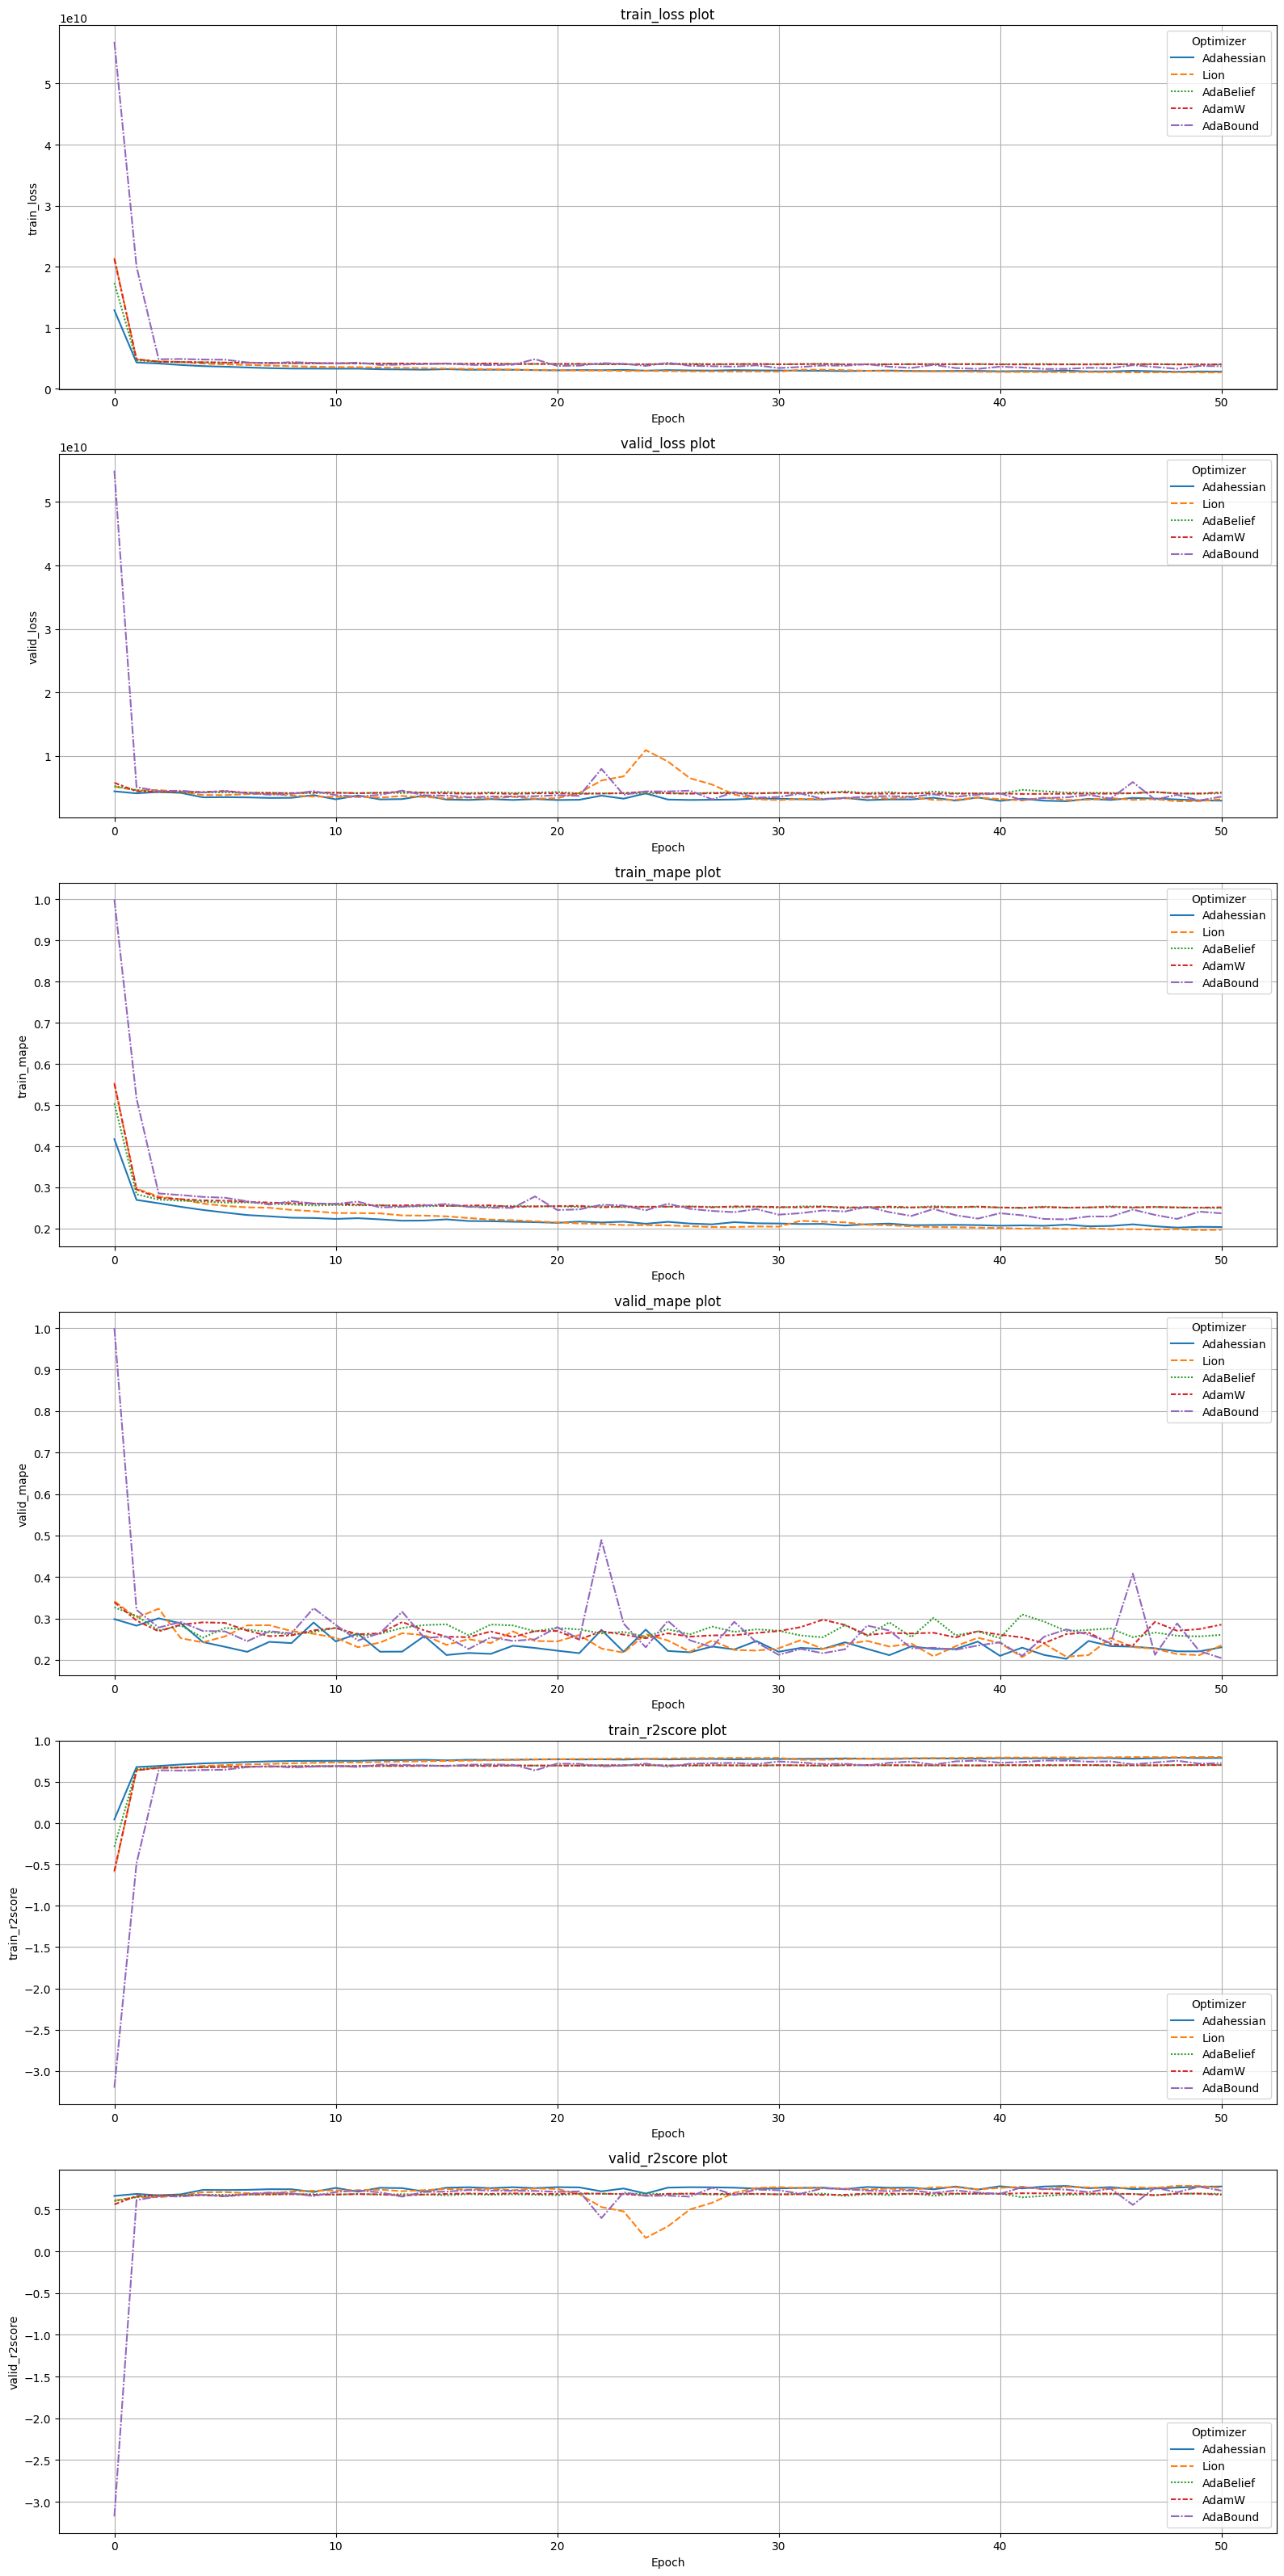

In [17]:
plot_results(results, test_num_epochs=TEST_NUM_EPOCHS, epoch_step=TEST_EPOCH_STEP, exclude_metrics=['time_training'])

Можем видеть достаточно большой loss для AdaBound в начале обучения, зашумленность на всей кривой обучения. У Lion присутствует достаточно сильный пик примерно на 25 эпохе. Все оптимизаторы имеют достаточно схожую скорость сходимости.  